# mencari kata kunci pada berita

## preprocessing text

import library

In [87]:
import pandas as pd
import nltk
import re
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
from itertools import combinations


load data

In [88]:
df = pd.read_csv('berita_kompas.csv')
df.head()

,judul,isi,tanggal,kategori
0,"Tiga Pengeroyok di Cakung Ditangkap, Satu Lain...","JAKARTA, KOMPAS.com - Jajaran Satreskrim Polre...","Kompas.com - 10/09/2024, 12:27 WIB",Megapolitan
1,Puan Beri Sinyal RUU Perampasan Aset Tak Disel...,"JAKARTA, KOMPAS.com - Ketua DPR RI Puan Mahara...","Kompas.com - 10/09/2024, 12:26 WIB",Nasional
2,PDI-P Duga Gugatan SK Kepengurusan Upaya Sabot...,"JAKARTA, KOMPAS.com - Ketua Dewan Pimpinan Pus...","Kompas.com - 10/09/2024, 12:24 WIB",Nasional
3,Jalan Jatiwaringin Bekasi Arah Jakarta Macet I...,"BEKASI, KOMPAS.com - Arus lalu lintas di Jalan...","Kompas.com - 10/09/2024, 12:17 WIB",Megapolitan
4,Nasib Taruna Akpol Usai Dipecat karena Lawan P...,"JAKARTA, KOMPAS.com - Taruna Akpol berinisial...","Kompas.com - 10/09/2024, 12:16 WIB",Nasional


preprocessing data

In [89]:
def preptext(text):
    text = re.sub(r'((www\.[^\s]+)|(https?://[^\s]+))', ' ', text) # Menghapus https* and www*
    text = re.sub(r'[\s]+', ' ', text) # Menghapus tambahan spasi
    text = re.sub(r"[^a-zA-Z :\.]", "", text) # Menghapus tanda baca
    text = re.sub(r'\d', ' ', text)#menghapus angka
    text = re.sub(r'#([^\s]+)', ' ', text)#menghapus hashtag
    words = word_tokenize(text.lower())

    sw = set(stopwords.words("indonesian"))
    words = [word for word in words if word.lower() not in sw]
    return ' '.join(words)

df['isi_baru'] = df['isi'].apply(preptext)
print(df['isi_baru'].head())
df['isi_baru'].to_csv('isi-baru.csv', index=False)

0    jakarta kompas.com jajaran satreskrim polres m...
1    jakarta kompas.com ketua dpr ri puan maharani ...
2    jakarta kompas.com ketua dewan pimpinan pusat ...
3    bekasi kompas.com arus lintas jalan jatiwaring...
4    jakarta kompas.com taruna akpol berinisial bva...
Name: isi_baru, dtype: object


memisahkan kalimat

In [90]:
kalimat = nltk.sent_tokenize(df['isi_baru'][1])
kalimat = [sentence.replace('.','') for sentence in kalimat]
kata = nltk.word_tokenize(df['isi_baru'][1])
kata = list(set(key for key in kata if key != '.'))

kalimat

['jakarta kompascom ketua dpr ri puan maharani sinyal menuntaskan rancangan undangundang perampasan aset tindak pidana periode ',
 'puan menyebut kerja dpr periode ',
 'pendek ',
 'anggota dpr periode puan gedung mprdpr ri jakarta selasa ',
 'dpr fokus menuntaskan kerjakerjanya periodenya ',
 'dpr ri periode kerjanya oktober ',
 'baca : sahroni utamakan pengembalian kerugian negara icw sindir ruu perampasan aset mandek dpr fokus halhal selesaikan tanggal oktober ',
 'ruu perampasan aset bahas periode ',
 'tunggu pergantian periode menyelesaikan halhal diselesaikan ',
 'wakil ketua komisi iii dpr ri ahmad sahroni rancangan undangundang perampasan aset tindak pidana disahkan sisa jabatan dpr periode ',
 'sahroni permintaan presiden jokowi ruu perampasan aset disahkan sulit terwujud jabatan anggota dpr periode tersisa hitungan ',
 'jokowi ruu perampasan aset diselesaikan ',
 'sidang tinggal pembahasan dilanjutkan periode sidang sahroni ditemui minggu ',
 'baca : jokowi komisi iii ruu pera

In [91]:
kata

['sulit',
 'wakil',
 'negara',
 'kendala',
 'tanggal',
 'partai',
 'halhal',
 'membahas',
 'dilanjutkan',
 'proses',
 'ruu',
 'fraksi',
 'komisi',
 'kompas.com',
 'jakarta',
 'pengembalian',
 'diselesaikan',
 ':',
 'sindir',
 'jokowi',
 'periode',
 'kerugian',
 'iii',
 'ketua',
 'permintaan',
 'oktober',
 'terwujud',
 'dpr',
 'maharani',
 'pembahasannya',
 'menuntaskan',
 'minggu',
 'hitungan',
 'nasdem',
 'sahroni',
 'pembahasan',
 'icw',
 'bahas',
 'sidang',
 'kerja',
 'menyebut',
 'tunggu',
 'periodenya',
 'mendesak',
 'aspek',
 'gedung',
 'mengesahkan',
 'disahkan',
 'baca',
 'fokus',
 'sisa',
 'mengeklaim',
 'mandek',
 'ahmad',
 'pergantian',
 'perampasan',
 'politikus',
 'selasa',
 'aset',
 'pengesahan',
 'kerjakerjanya',
 'pendek',
 'keterbatasan',
 'terkait',
 'jabatan',
 'mendalam',
 'mprdpr',
 'puan',
 'ditemui',
 'ri',
 'uu',
 'rancangan',
 'tinggal',
 'menyelesaikan',
 'utamakan',
 'utama',
 'tindak',
 'komprehensif',
 'undangundang',
 'anggota',
 'tersisa',
 'pidana',
 'se

membuat matrix

In [92]:
def vektor_kata(data):
    vektor_kata = pd.DataFrame(0, index=range(len(data)), columns=kata)
    
    for i, sent in enumerate(data):
        # Tokenisasi kalimat menjadi kata-kata
        kata_kalimat = word_tokenize(sent)
        
        # Hitung frekuensi kata menggunakan Counter
        freq_kata = Counter(kata_kalimat)
        
        # Update DataFrame dengan frekuensi kata yang ditemukan dalam kata
        for word, count in freq_kata.items():
            if word in kata:
                vektor_kata.at[i, word] = count

    return vektor_kata

vektorisasi_kata = vektor_kata(kalimat)
print(vektorisasi_kata)

    sulit  wakil  negara  kendala  tanggal  partai  halhal  membahas  \
0       0      0       0        0        0       0       0         0   
1       0      0       0        0        0       0       0         0   
2       0      0       0        0        0       0       0         0   
3       0      0       0        0        0       0       0         0   
4       0      0       0        0        0       0       0         0   
5       0      0       0        0        0       0       0         0   
6       0      0       1        0        1       0       1         0   
7       0      0       0        0        0       0       0         0   
8       0      0       0        0        0       0       1         0   
9       0      1       0        0        0       0       0         0   
10      1      0       0        0        0       0       0         0   
11      0      0       0        0        0       0       0         0   
12      0      0       0        0        0       0       0      

hasil kata kunci

In [93]:
kunci = vektorisasi_kata.sum().sort_values(ascending=False)[:4]
print(", ".join(kunci.index))

dpr, periode, perampasan, aset


co-occurrence matrix

In [94]:
def cooc_matrix(data):
    vektor_kata = pd.DataFrame(0, index=kata, columns=kata)
    
    for sent in data:
        kata_kalimat = word_tokenize(sent)
        
        for word1, word2 in combinations(kata_kalimat, 2):#mencari kata yg sering muncul menggunakan combination
            if word1 in kata and word2 in kata:
                # Tambahkan ke matrix untuk kedua arah (word1, word2) dan (word2, word1)
                vektor_kata.at[word1, word2] += 1
                vektor_kata.at[word2, word1] += 1

    return vektor_kata

# Contoh pemanggilan fungsi
cooccurrence_matrix = cooc_matrix(kalimat)
print(cooccurrence_matrix)

            sulit  wakil  negara  kendala  tanggal  partai  halhal  membahas  \
sulit           0      0       0        0        0       0       0         0   
wakil           0      0       0        0        0       0       0         0   
negara          0      0       0        0        1       0       1         0   
kendala         0      0       0        0        0       1       0         0   
tanggal         0      0       1        0        0       0       1         0   
...           ...    ...     ...      ...      ...     ...     ...       ...   
selesaikan      0      0       1        0        1       0       1         0   
presiden        1      0       0        0        0       0       0         0   
kerjanya        0      0       0        0        0       0       0         0   
realistis       0      0       0        0        0       0       0         0   
sinyal          0      0       0        0        0       0       0         0   

            dilanjutkan  proses  ...  k

cosine similaritas

In [95]:
cosine = cosine_similarity(cooccurrence_matrix)
cosine

array([[1.        , 0.46188022, 0.30429031, ..., 0.25819889, 0.09759001,
        0.27602622],
       [0.46188022, 1.        , 0.26352314, ..., 0.4472136 , 0.08451543,
        0.65737574],
       [0.30429031, 0.26352314, 1.        , ..., 0.23570226, 0.08908708,
        0.18898224],
       ...,
       [0.25819889, 0.4472136 , 0.23570226, ..., 1.        , 0.        ,
        0.40089186],
       [0.09759001, 0.08451543, 0.08908708, ..., 0.        , 1.        ,
        0.        ],
       [0.27602622, 0.65737574, 0.18898224, ..., 0.40089186, 0.        ,
        1.        ]])

buat dalam bentuk graph

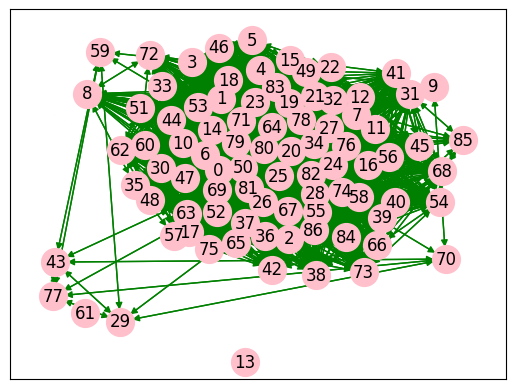

In [96]:
G = nx.DiGraph()
for i in range(len(cosine)):
    G.add_node(i)

for i in range(len(cosine)):
    for j in range(len(cosine)):
        similarity = cosine[i][j]
        if similarity > 0.1 and i != j:
            G.add_edge(i, j)

pos = nx.spring_layout(G, k=2)
nx.draw_networkx_nodes(G, pos, node_size=400, node_color='pink')
nx.draw_networkx_edges(G, pos, edge_color='green', arrows=True)
nx.draw_networkx_labels(G, pos)

plt.show()

In [97]:
rank_word = nx.pagerank(G)

sorted_pagerank= sorted(rank_word.items(), key=lambda x: x[1], reverse=True)
print("Page Rank :")
for node, pagerank in sorted_pagerank:
    print(f"Node {node}: {pagerank:.4f}")

Page Rank :
Node 20: 0.0138
Node 34: 0.0138
Node 64: 0.0138
Node 69: 0.0135
Node 71: 0.0135
Node 76: 0.0135
Node 78: 0.0135
Node 79: 0.0135
Node 80: 0.0135
Node 81: 0.0135
Node 83: 0.0135
Node 0: 0.0135
Node 6: 0.0135
Node 23: 0.0135
Node 24: 0.0135
Node 25: 0.0135
Node 26: 0.0135
Node 27: 0.0135
Node 32: 0.0135
Node 55: 0.0131
Node 58: 0.0131
Node 67: 0.0131
Node 1: 0.0130
Node 47: 0.0130
Node 50: 0.0130
Node 53: 0.0130
Node 14: 0.0130
Node 37: 0.0128
Node 16: 0.0126
Node 10: 0.0125
Node 28: 0.0125
Node 86: 0.0125
Node 36: 0.0121
Node 52: 0.0121
Node 74: 0.0121
Node 82: 0.0121
Node 2: 0.0121
Node 4: 0.0121
Node 15: 0.0121
Node 18: 0.0121
Node 21: 0.0121
Node 19: 0.0121
Node 7: 0.0120
Node 11: 0.0120
Node 12: 0.0120
Node 22: 0.0120
Node 30: 0.0120
Node 44: 0.0120
Node 49: 0.0120
Node 63: 0.0120
Node 65: 0.0120
Node 84: 0.0119
Node 9: 0.0117
Node 29: 0.0117
Node 43: 0.0117
Node 59: 0.0117
Node 70: 0.0117
Node 77: 0.0117
Node 39: 0.0116
Node 40: 0.0116
Node 17: 0.0112
Node 48: 0.0112
Nod

In [99]:
print("Empat Node Tertinggi Page Rank :")
sentence = ""
for node, pagerank in sorted_pagerank[:4]:
  top_sentence = kata[node]
  sentence += top_sentence + ", "
  print(f"Node {node}: Page Rank = {pagerank:.4f}")
  print(f"kata: {top_sentence}")

Empat Node Tertinggi Page Rank :
Node 20: Page Rank = 0.0138
kata: periode
Node 34: Page Rank = 0.0138
kata: sahroni
Node 64: Page Rank = 0.0138
kata: jabatan
Node 69: Page Rank = 0.0135
kata: ri
